In [ ]:
from typing import cast

import pandas as pd
from scipy.spatial import KDTree
from dask.dataframe import DataFrame as DaskDataFrame
import numpy as np
from numpy.random import default_rng
from numpy.typing import NDArray
import itertools
import logging
from dummy_spatialdata import generate_dataset
import dummy_anndata
import spatialdata_plot
import spatialdata as sd
import matplotlib.pyplot as plt
import anndata as ad

ValidNumericNDArray = (
    NDArray[np.uint8]
    | NDArray[np.int8]
    | NDArray[np.uint16]
    | NDArray[np.int16]
    | NDArray[np.uint32]
    | NDArray[np.int32]
    | NDArray[np.float32]
)

SUPPORTED_DTYPES = [
    np.float64,
    np.uint32,
    np.int32,
    np.float32,
    np.uint16,
    np.int16,
    np.uint8,
    np.int8,
    "category",
]

RNG = default_rng(42)

logger = logging.getLogger(__name__)

c:\Users\stock\miniconda3\envs\sdata\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# generate anndata
adata = dummy_anndata.generate_dataset(n_obs=12, n_vars=20)

# generate spatialdata
sdata = generate_dataset(
    images = [
        {'type': 'rgb', 'scale_factors': [2,2,2], 'coordinate_system': 'global'},
        {'type': 'grayscale', 'coordinate_system': 'global'},
    ],
    labels = [
        {'n': 12, 'scale_factors': [2,2,3], 'coordinate_system': 'global'},
        {'n': 12, 'coordinate_system': 'global'},
    ], 
    shapes = [
        {'n': 12, 'type': 'circle', 'coordinate_system': 'global'},
        {'n': 20, 'type': 'circle', 'coordinate_system': 'global'},
    ],
    points = [
        {'n': 500000, 'coordinate_system': 'global'} # NOTE: change n for altering the point numbers
    ],
    tables = [
        {'table': adata, 'element': 'shape', 'element_index': 0}
    ],
    coordinate_systems = {
        'global': {'transformations': ['identity'], 'shape': {'x': 2000, 'y': 2000}},
    },
    SEED=13
)

In [ ]:
# add a z dimension since the tissue-map-tools code expects 3D data
points = sdata["point_0"]
points["z"] = 1

---

In [ ]:
# Code from https://github.com/hms-dbmi/tissue-map-tools/blob/main/src/tissue_map_tools/data_model/annotations.py

class GridLevel:
    def __init__(
        self,
        level: int,
        grid_shape: tuple[int, ...],
        mins: NDArray[np.float64],
        maxs: NDArray[np.float64],
        limit: int,
        parent_cells: list[tuple[int, ...]],
        parent_grid_shape: tuple[int, ...],
    ) -> None:
        self.level: int = level
        self.grid_shape: tuple[int, ...] = grid_shape
        self.mins: NDArray[np.float64] = mins
        self.maxs: NDArray[np.float64] = maxs
        self.limit: int = limit

        # quantities derived in this function call
        self.sizes: NDArray[np.float64] = np.array(maxs) - np.array(mins)
        self.chunk_size: NDArray[np.float64] = self.sizes / np.array(self.grid_shape)
        self.cells: list[tuple[int, ...]] = []

        # quantities set later
        self.populated_cells: dict[tuple[int, ...], NDArray[np.float64]] = {}

        if len(self.mins) != 3 or len(self.maxs) != 3:
            raise NotImplementedError("GridLevel only supports 3D grids at the moment.")

        for parent_cell in parent_cells:
            new_cells_by_dim: dict[int, tuple[int, ...]] = {}
            for dim in range(3):
                index = parent_cell[dim]
                factor = grid_shape[dim] // parent_grid_shape[dim]
                if factor == 1:
                    new_cells_by_dim[dim] = (index,)
                else:
                    new_cells_by_dim[dim] = (index * factor, index * factor + 1)
            new_cells = cast(
                list[tuple[int, ...]],
                itertools.product(*new_cells_by_dim.values()),
            )
            self.cells.extend(new_cells)

    def iter_cells(self):
        for i, j, k in self.cells:
            yield (i, j, k)

    def centroid(self, cell: tuple[int, ...]) -> NDArray[np.float64]:
        """Calculate the centroid of the grid cell."""
        return np.array(cell) * self.chunk_size + self.chunk_size / 2 + self.mins

    def get_next_grid_shape(self) -> tuple[int, ...]:
        """Get the shape of the next grid level so that we get isotropic chunks.

        Notes
        -----
        The specs say: "each component of chunk_size of each successively level
        should be either equal to, or half of, the corresponding component of the
        prior level chunk_size, whichever results in a more spatially isotropic
        chunk."

        We implement this as follows: if a chunk length for a given axis is half
        (or less) than the size of any other chunk, then we leave this axis as is,
        otherwise we divide the chunk size by 2 (i.e. we multiply the grid shape by 2).
        """
        next_grid_shape = list(self.grid_shape)
        for i in range(3):
            if any(
                [
                    self.chunk_size[i] * 2 <= self.chunk_size[j].item()
                    for j in range(3)
                    if j != i
                ]
            ):
                continue
            else:
                next_grid_shape[i] *= 2
        return tuple(next_grid_shape)


def get_coordinates_and_kd_tree(
    points: pd.DataFrame | DaskDataFrame,
) -> tuple[ValidNumericNDArray, KDTree]:
    """
    Extract xyz coordinates and create a KDTree.
    """
    # TODO: we can generalize to 2D points. 1D points do not make much sense. If we
    #  only have 1D or 2D point the following line will throw an error.
    if isinstance(points, DaskDataFrame):
        xyz = points[["x", "y", "z"]].compute().values
    else:
        xyz = points[["x", "y", "z"]].values
    dtype = xyz.dtype
    if not (
        dtype in SUPPORTED_DTYPES
        and (np.issubdtype(dtype, np.integer) or np.issubdtype(dtype, np.floating))
    ):
        # TODO: make a test for this
        raise TypeError(
            f"Unsupported type for xyz coordinates: {type(xyz).__name__}. Supported "
            f"types are numerical types from: {SUPPORTED_DTYPES}."
        )
    kd_tree = KDTree(xyz)
    return xyz, kd_tree


def compute_spatial_index(
    xyz: ValidNumericNDArray,
    kd_tree: KDTree | None = None,
    limit: int = 1000,
    starting_grid_shape: tuple[int, ...] | None = None,
    PRINT_DEBUG: bool = False,
    VISUAL_DEBUG: bool = False,
) -> dict[int, GridLevel]:
    # TODO: only points are supported at the moment, not lines, axis-aligned bounding
    #  boxes and ellipsoids
    # TODO: allows to pass multiple limit values, not just a single one for all the
    #  index levels
    if starting_grid_shape is None:
        starting_grid_shape = (1, 1, 1)

    if kd_tree is None:
        kd_tree = KDTree(xyz)

    mins = np.min(xyz, axis=0)
    maxs = np.max(xyz, axis=0)

    remaining_indices = set(range(len(xyz)))

    # the default case is that starting_grid_shape is (1, 1, 1), which means that
    # parent_cells is [(0, 0, 0)].
    parent_cells = list(itertools.product(*[range(s) for s in starting_grid_shape]))

    grid: dict[int, GridLevel] = {}
    grid_level = GridLevel(
        level=0,
        grid_shape=starting_grid_shape,
        mins=mins,
        maxs=maxs,
        limit=limit,
        parent_cells=parent_cells,
        parent_grid_shape=starting_grid_shape,
    )
    # to avoid the risk of points in the boundary of the grid not being included;
    # eps must be relative to the coordinate magnitude, otherwise for large float
    # values, an absolute eps gets swallowed by floating point precision
    coordinate_magnitude = max(np.abs(mins).max(), np.abs(maxs).max())
    # magnitude * dtype_eps gives a ULP (unit in the last place)
    # we multiply this by a small factor (2)
    if not (
        np.issubdtype(xyz.dtype, np.floating) or np.issubdtype(xyz.dtype, np.integer)
    ):
        raise TypeError(f"Expected numerical dtype for xyz, got {xyz.dtype}")
    eps = max(1e-6, float(coordinate_magnitude * np.finfo(xyz.dtype).eps * 2))  # type: ignore[type-var]
    len_previous_remaining_indices = len(remaining_indices)

    while len(remaining_indices) > 0:
        # initialization
        grid[grid_level.level] = grid_level
        if PRINT_DEBUG:
            print(
                f"Processing grid level {grid_level.level} with shape {grid_level.grid_shape} "
                f"and chunk size {grid_level.chunk_size}. Remaining points: {len(remaining_indices)}"
            )

        # Pass 1: gather remaining indices per cell
        indices_per_cell: dict[tuple[int, ...], list[int]] = {}
        for i, j, k in grid_level.iter_cells():
            centroid = grid_level.centroid((i, j, k))

            # find points in the grid cell
            # this filters points by a radius r, but we have different values per axis,
            # so we proceed with manual filtering on the result from the kDTree query
            indices = kd_tree.query_ball_point(
                centroid, r=grid_level.chunk_size.max().item() / 2 + eps, p=np.inf
            )
            filtered = xyz[indices]
            half = grid_level.chunk_size / 2
            mask = (
                (centroid[0] - half[0] - eps <= filtered[:, 0])
                & (filtered[:, 0] <= centroid[0] + half[0] + eps)
                & (centroid[1] - half[1] - eps <= filtered[:, 1])
                & (filtered[:, 1] <= centroid[1] + half[1] + eps)
                & (centroid[2] - half[2] - eps <= filtered[:, 2])
                & (filtered[:, 2] <= centroid[2] + half[2] + eps)
            )
            discarded = np.sum(~mask).item()
            if discarded > 0:
                # TODO: **possible bug!** This message is not printed while I would
                #  expect that the kDTree query would sometimes return more points than
                #  the mask would allow (this should happen when chunk_size has
                #  different dimensions)
                logger.warning(
                    f"{discarded} points were filtered out of {len(indices)} "
                    f"during spatial index computation"
                )
            indices = np.array(indices)[mask].tolist()

            # filter out points that have been previously emitted
            indices = [idx for idx in indices if idx in remaining_indices]

            if len(indices) > 0:
                indices_per_cell[(i, j, k)] = indices

        # Pass 2: compute a single global sampling probability from the densest
        # cell, and apply it uniformly to all cells. This preserves relative
        # density across cells: e.g. a cell with 10x more points will emit ~10x more
        # annotations, rather than being clamped to the same `limit`.
        # See https://github.com/google/neuroglancer/issues/227#issuecomment-916384909
        if indices_per_cell:
            max_count = max(len(v) for v in indices_per_cell.values())
            p = min(1.0, limit / max_count)

            for cell, indices in indices_per_cell.items():
                # Re-filter: exclude annotations already emitted by an earlier
                # cell in this same level (e.g. an annotation spanning multiple
                # cells would otherwise be emitted more than once).
                indices = [idx for idx in indices if idx in remaining_indices]
                if not indices:
                    continue
                indices_arr = np.array(indices)
                keep = RNG.random(len(indices)) < p
                emitted = indices_arr[keep].tolist()
                # Neuroglancer subsamples by taking a prefix of the stored list,
                # so we shuffle to ensure the prefix is spatially representative.
                RNG.shuffle(emitted)
                if PRINT_DEBUG:
                    print(f"Emitting {len(emitted)} points for grid cell {cell}")
                # Always register the cell, even if nothing was sampled this level.
                # An empty entry ensures the cell is expanded at the next level so
                # its remaining annotations can still be emitted there.
                grid_level.populated_cells[cell] = emitted
                remaining_indices.difference_update(emitted)

        if VISUAL_DEBUG:
            import matplotlib.pyplot as plt

            plt.figure(figsize=(10, 10))
            chunk_size = grid_level.chunk_size
            lines_x = np.arange(
                grid_level.mins[0],
                grid_level.maxs[0] + chunk_size[0],
                chunk_size[0] + eps,
            )
            lines_y = np.arange(
                grid_level.mins[1],
                grid_level.maxs[1] + chunk_size[1],
                chunk_size[1] + eps,
            )
            for x in lines_x:
                plt.plot(
                    [x, x],
                    [grid_level.mins[1], grid_level.maxs[1]],
                    color="red",
                    linewidth=0.5,
                )
            for y in lines_y:
                plt.plot(
                    [grid_level.mins[0], grid_level.maxs[0]],
                    [y, y],
                    color="red",
                    linewidth=0.5,
                )

            remaining_xyz = xyz[list(remaining_indices)]
            plt.scatter(
                remaining_xyz[:, 0],
                remaining_xyz[:, 1],
                s=100,
                c=remaining_xyz[:, 2],
            )
            if len(remaining_xyz) > 0:
                cbar = plt.colorbar()
                cbar.set_ticks([remaining_xyz[:, 2].min(), remaining_xyz[:, 2].max()])
                cbar.set_ticklabels(
                    [f"{remaining_xyz[:, 2].min()}", f"{remaining_xyz[:, 2].max()}"]
                )
            plt.show()

        # prepare for the next level
        grid_level = GridLevel(
            level=grid_level.level + 1,
            grid_shape=grid_level.get_next_grid_shape(),
            mins=grid_level.mins,
            maxs=grid_level.maxs,
            limit=limit,
            parent_cells=list(grid_level.populated_cells.keys()),
            parent_grid_shape=grid_level.grid_shape,
        )

        # sanity check
        if len(remaining_indices) == len_previous_remaining_indices:
            raise ValueError(
                "No points were emitted in this grid level. This is likely due to the "
                "grid size being too small. To fix, try increasing the `limit` "
                "parameter."
            )
        len_previous_remaining_indices = len(remaining_indices)
    return grid

In [66]:
xyz, kd_tree = get_coordinates_and_kd_tree(points)

Processing grid level 0 with shape (1, 1, 1) and chunk size [1999.98674044 1999.98672759    0.        ]. Remaining points: 500000
Emitting 1074 points for grid cell (0, 0, 0)


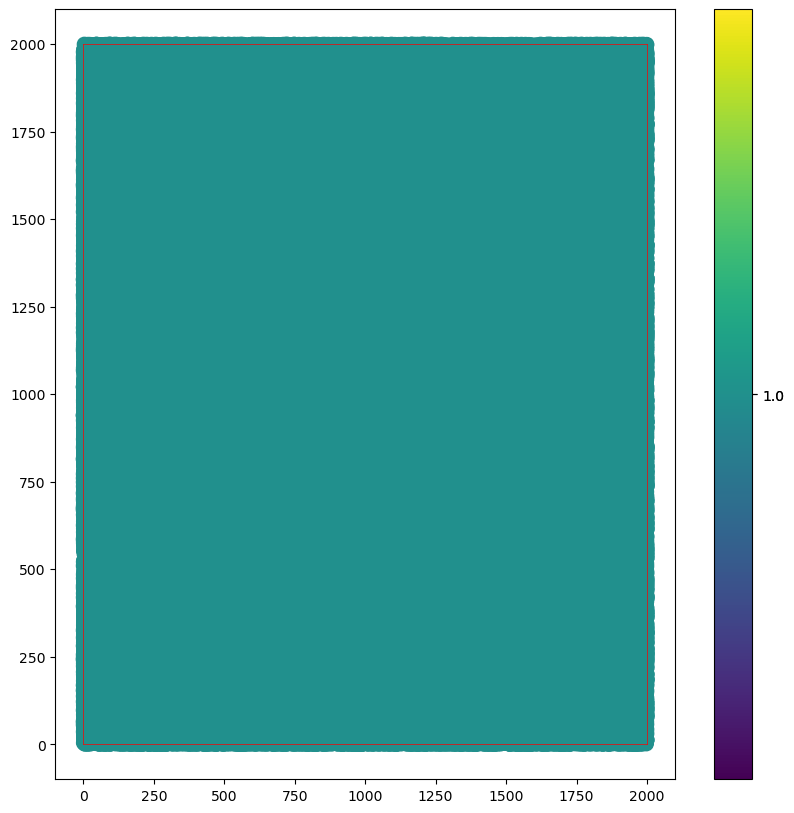

Processing grid level 1 with shape (2, 2, 1) and chunk size [999.99337022 999.9933638    0.        ]. Remaining points: 498926
Emitting 974 points for grid cell (0, 0, 0)
Emitting 933 points for grid cell (0, 1, 0)
Emitting 936 points for grid cell (1, 0, 0)
Emitting 983 points for grid cell (1, 1, 0)


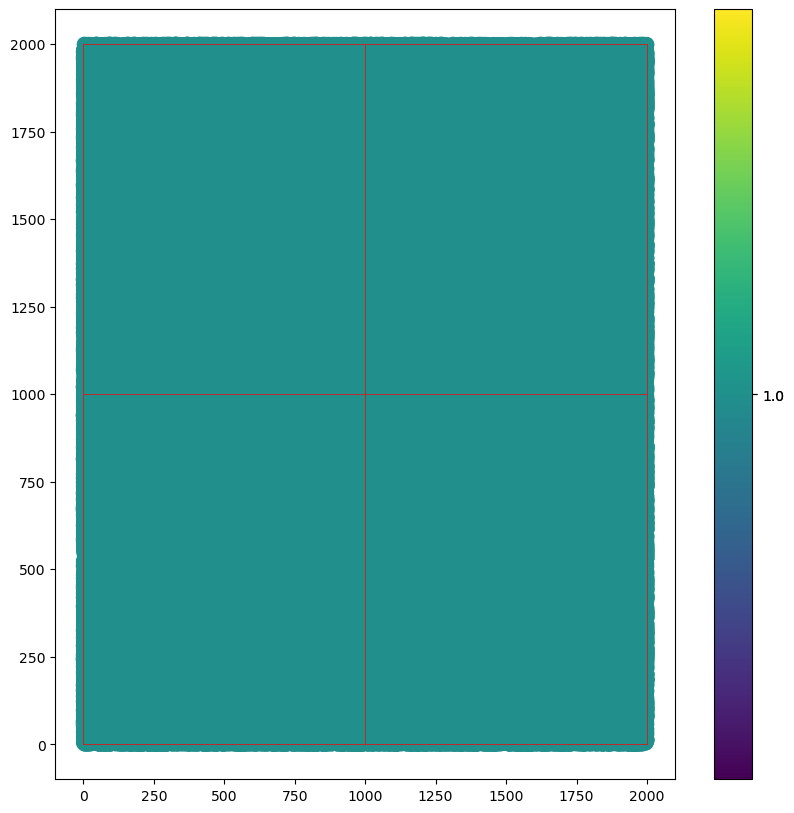

Processing grid level 2 with shape (4, 4, 1) and chunk size [499.99668511 499.9966819    0.        ]. Remaining points: 495100
Emitting 980 points for grid cell (0, 0, 0)
Emitting 962 points for grid cell (0, 1, 0)
Emitting 985 points for grid cell (1, 0, 0)
Emitting 982 points for grid cell (1, 1, 0)
Emitting 994 points for grid cell (0, 2, 0)
Emitting 1031 points for grid cell (0, 3, 0)
Emitting 983 points for grid cell (1, 2, 0)
Emitting 970 points for grid cell (1, 3, 0)
Emitting 1014 points for grid cell (2, 0, 0)
Emitting 1011 points for grid cell (2, 1, 0)
Emitting 994 points for grid cell (3, 0, 0)
Emitting 983 points for grid cell (3, 1, 0)
Emitting 955 points for grid cell (2, 2, 0)
Emitting 1012 points for grid cell (2, 3, 0)
Emitting 969 points for grid cell (3, 2, 0)
Emitting 980 points for grid cell (3, 3, 0)


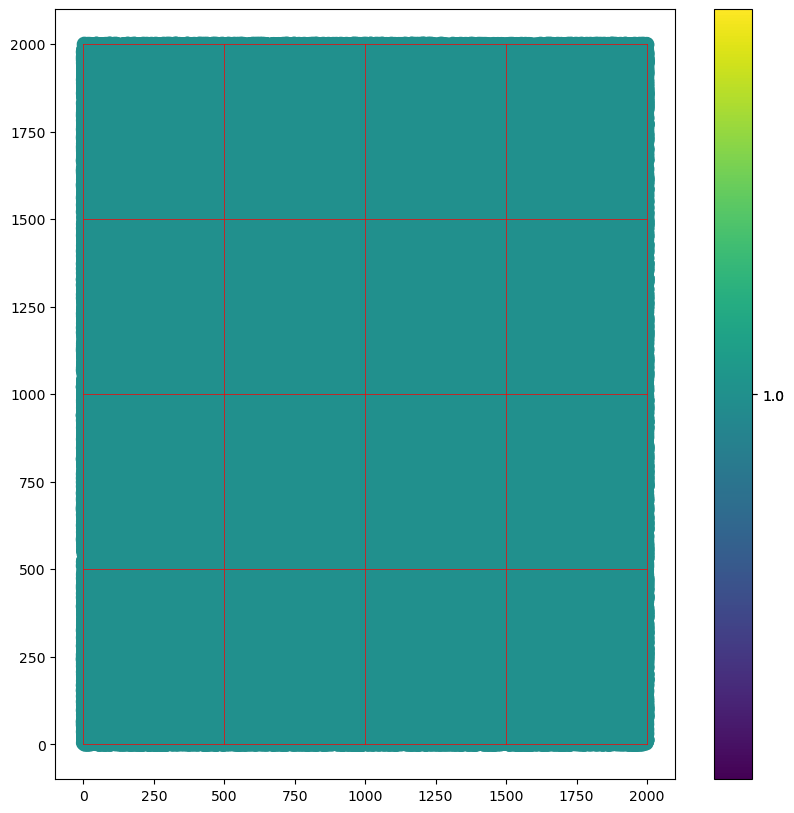

Processing grid level 3 with shape (8, 8, 1) and chunk size [249.99834255 249.99834095   0.        ]. Remaining points: 479295
Emitting 964 points for grid cell (0, 0, 0)
Emitting 1007 points for grid cell (0, 1, 0)
Emitting 1004 points for grid cell (1, 0, 0)
Emitting 1007 points for grid cell (1, 1, 0)
Emitting 970 points for grid cell (0, 2, 0)
Emitting 973 points for grid cell (0, 3, 0)
Emitting 982 points for grid cell (1, 2, 0)
Emitting 923 points for grid cell (1, 3, 0)
Emitting 1022 points for grid cell (2, 0, 0)
Emitting 977 points for grid cell (2, 1, 0)
Emitting 1003 points for grid cell (3, 0, 0)
Emitting 955 points for grid cell (3, 1, 0)
Emitting 916 points for grid cell (2, 2, 0)
Emitting 1035 points for grid cell (2, 3, 0)
Emitting 885 points for grid cell (3, 2, 0)
Emitting 981 points for grid cell (3, 3, 0)
Emitting 964 points for grid cell (0, 4, 0)
Emitting 982 points for grid cell (0, 5, 0)
Emitting 938 points for grid cell (1, 4, 0)
Emitting 976 points for grid ce

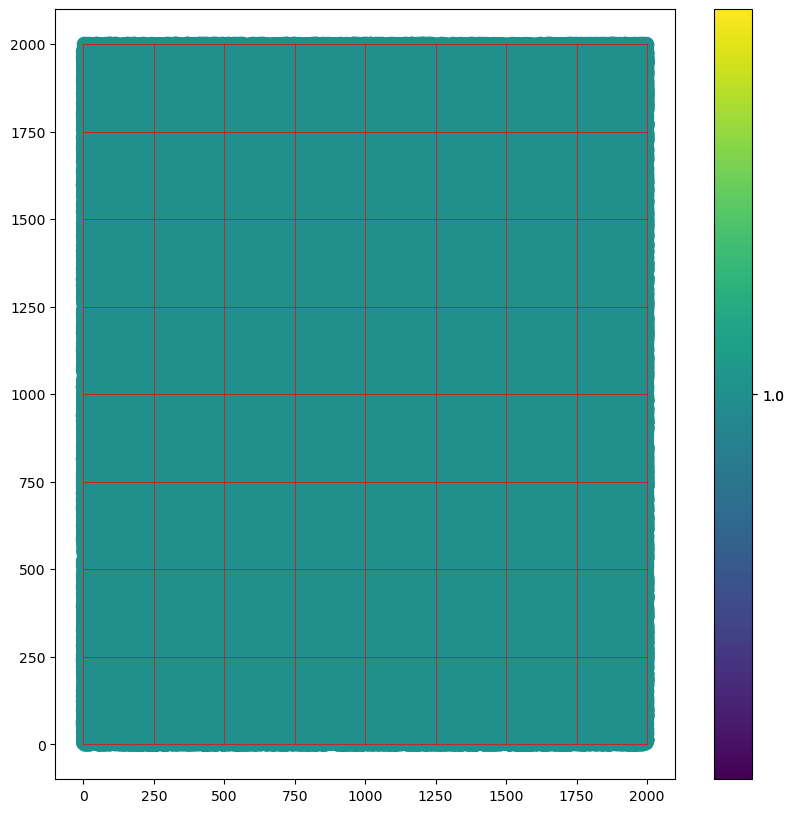

Processing grid level 4 with shape (16, 16, 1) and chunk size [124.99917128 124.99917047   0.        ]. Remaining points: 417200
Emitting 911 points for grid cell (0, 0, 0)
Emitting 889 points for grid cell (0, 1, 0)
Emitting 909 points for grid cell (1, 0, 0)
Emitting 978 points for grid cell (1, 1, 0)
Emitting 922 points for grid cell (0, 2, 0)
Emitting 887 points for grid cell (0, 3, 0)
Emitting 903 points for grid cell (1, 2, 0)
Emitting 882 points for grid cell (1, 3, 0)
Emitting 898 points for grid cell (2, 0, 0)
Emitting 912 points for grid cell (2, 1, 0)
Emitting 952 points for grid cell (3, 0, 0)
Emitting 988 points for grid cell (3, 1, 0)
Emitting 929 points for grid cell (2, 2, 0)
Emitting 985 points for grid cell (2, 3, 0)
Emitting 1003 points for grid cell (3, 2, 0)
Emitting 937 points for grid cell (3, 3, 0)
Emitting 881 points for grid cell (0, 4, 0)
Emitting 944 points for grid cell (0, 5, 0)
Emitting 907 points for grid cell (1, 4, 0)
Emitting 922 points for grid cell 

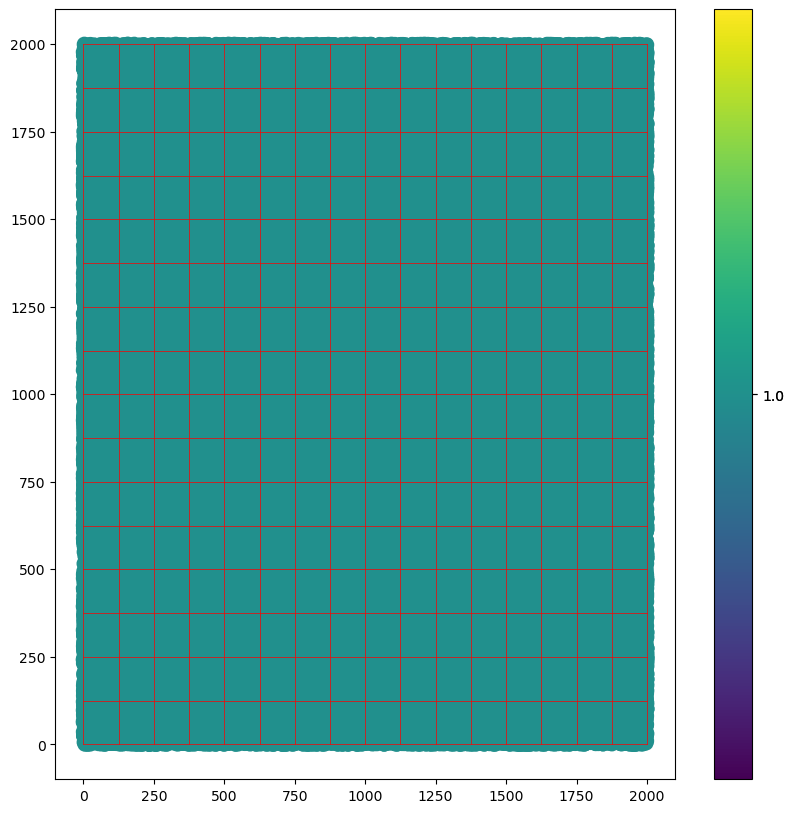

Processing grid level 5 with shape (32, 32, 1) and chunk size [62.49958564 62.49958524  0.        ]. Remaining points: 180227
Emitting 156 points for grid cell (0, 0, 0)
Emitting 207 points for grid cell (0, 1, 0)
Emitting 178 points for grid cell (1, 0, 0)
Emitting 178 points for grid cell (1, 1, 0)
Emitting 161 points for grid cell (0, 2, 0)
Emitting 174 points for grid cell (0, 3, 0)
Emitting 165 points for grid cell (1, 2, 0)
Emitting 172 points for grid cell (1, 3, 0)
Emitting 160 points for grid cell (2, 0, 0)
Emitting 189 points for grid cell (2, 1, 0)
Emitting 170 points for grid cell (3, 0, 0)
Emitting 191 points for grid cell (3, 1, 0)
Emitting 202 points for grid cell (2, 2, 0)
Emitting 174 points for grid cell (2, 3, 0)
Emitting 173 points for grid cell (3, 2, 0)
Emitting 196 points for grid cell (3, 3, 0)
Emitting 173 points for grid cell (0, 4, 0)
Emitting 177 points for grid cell (0, 5, 0)
Emitting 162 points for grid cell (1, 4, 0)
Emitting 159 points for grid cell (1, 

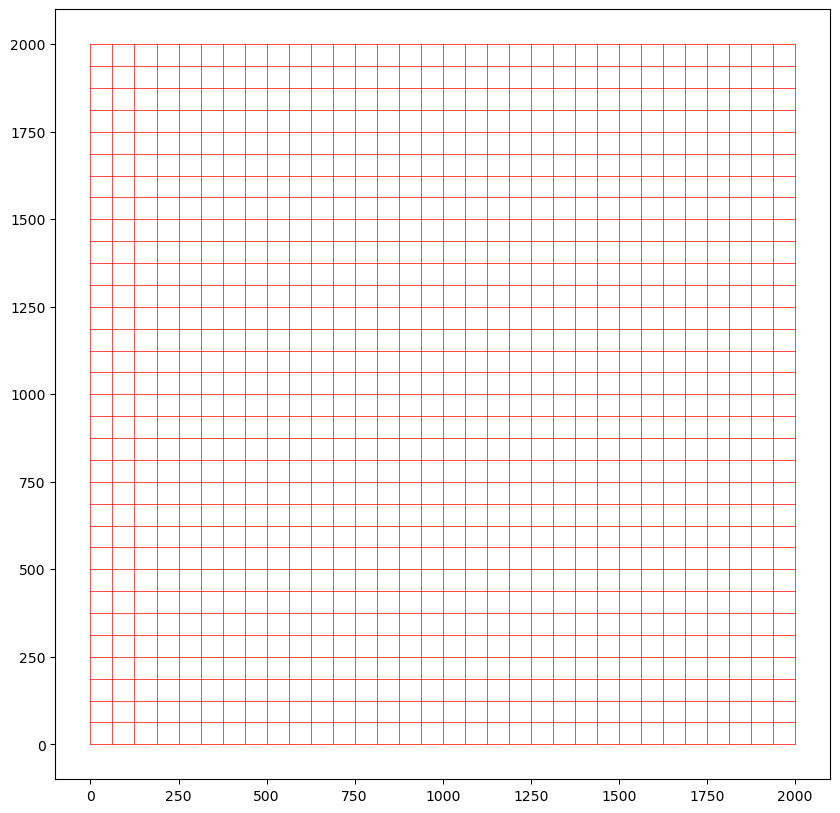

In [ ]:
grid = compute_spatial_index(xyz, kd_tree, PRINT_DEBUG=True, VISUAL_DEBUG=True)

In [71]:
grid

{0: <__main__.GridLevel at 0x1baa4650cd0>,
 1: <__main__.GridLevel at 0x1baa9d12c10>,
 2: <__main__.GridLevel at 0x1ba7796d810>,
 3: <__main__.GridLevel at 0x1ba641a3490>,
 4: <__main__.GridLevel at 0x1ba75eb85f0>,
 5: <__main__.GridLevel at 0x1ba774f5d00>}